# Scenario 2 – Boosting

**Name:** SaiSanjay R

**Roll No:** 24BAD102

Jaya Krishna G - 24BAD042
   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0
AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


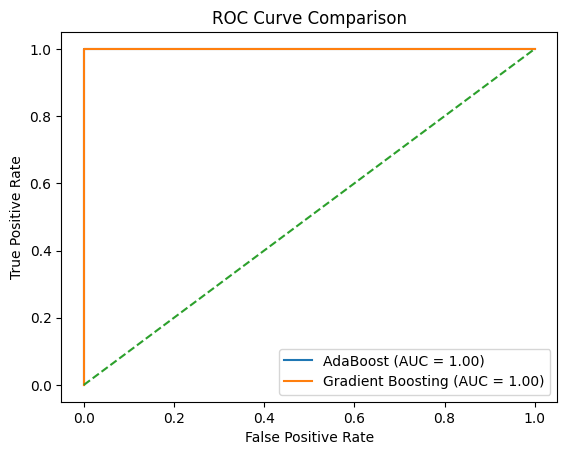

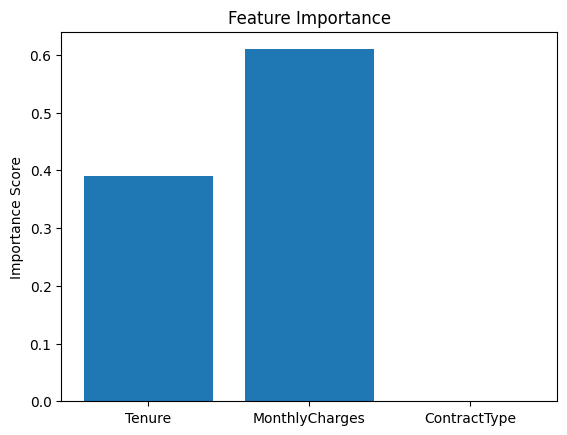

In [2]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

# 2. Load Dataset
df = pd.read_csv("churn_boosting.csv")

print(df.head())

# 3. Encode Categorical Variables
le = LabelEncoder()
df['ContractType'] = le.fit_transform(df['ContractType'])
df['Churn'] = le.fit_transform(df['Churn'])

# 4. Define Features and Target
X = df[['Tenure','MonthlyCharges','ContractType']]
y = df['Churn']

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Train AdaBoost
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

# 7. Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

print("AdaBoost Accuracy:", acc_ada)
print("Gradient Boosting Accuracy:", acc_gb)

# 8. ROC Curve
y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

roc_auc_ada = auc(fpr_ada, tpr_ada)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.plot(fpr_ada, tpr_ada, label="AdaBoost (AUC = %0.2f)" % roc_auc_ada)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %0.2f)" % roc_auc_gb)

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# 9. Feature Importance Plot (Gradient Boosting)
importance = gb.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()